# Exploratory Data Analysis — Restaurant Branch Performance

## Introduction

This notebook performs Exploratory Data Analysis (EDA) on the Restaurant Branch Performance Dataset using Python and Pandas.
The objective is to understand the structure of the dataset, summarize important variables, analyze distributions, compare restaurant performance across branches, regions, and store types, and identify relationships between numerical variables using correlation analysis.

The analysis focuses on important business factors such as:

- Customers
- Orders
- Revenue
- Profit
- Marketing Spend
- Staff Count
- Average Delivery Time
- Customer Rating
- Average Bill

## 1. Importing Required Libraries

The following Python libraries are used for data analysis and visualization:
- **Pandas** — for data loading, cleaning, manipulation, and analysis.
- **NumPy** — for numerical operations.
- **Matplotlib** — for creating visualizations.
- **Seaborn** — for statistical visualizations and correlation heatmaps.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

The restaurant branch performance dataset is loaded into a Pandas DataFrame.
The `read_csv()` function is used because the dataset is provided in CSV format.

In [4]:
df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset.csv")
df.head()


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [5]:
df.tail()

,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
345,ST0346,2026-02-08,Sunday,February,Mumbai,West,Express,10,7389.17,202,...,56852.25,18863.88,43733.92,13118.33,27.2,4.63,28.9,64.6,Rain,NaN
346,ST0347,2026-06-05,Friday,June,Mumbai,West,Premium,12,8398.13,274,...,138198.35,50914.04,75370.62,62827.73,35.4,4.32,22.7,57.9,Rain,NaN
347,ST0348,2026-03-13,Friday,March,Bengaluru,South,Standard,16,2876.93,196,...,62974.97,23946.23,51377.97,11597.00,22.5,4.51,32.3,63.4,Clear,Combo Deal
348,ST0349,2026-03-10,Tuesday,March,Jaipur,North,Standard,9,4731.74,200,...,78451.05,26050.73,47400.29,31050.76,28.3,4.51,24.7,58.6,Clear,Loyalty Offer
349,ST0350,2026-02-03,Tuesday,February,Pune,West,Standard,16,7004.28,225,...,86122.21,28144.81,54734.11,31388.10,22.7,4.30,32.0,83.9,Clear,NaN


## 3. Understanding the Dataset

Before performing detailed analysis, we inspect the dataset to understand:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Basic statistical information

This helps us understand the quality and structure of the data before continuing with EDA.

In [6]:
df.shape

(350, 22)

In [7]:
df.columns

Index(['Record_ID', 'Date', 'Day', 'Month', 'Branch', 'Region', 'Store_Type',
       'Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill',
       'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min',
       'Customer_Rating', 'Temperature_C', 'Humidity_Percent', 'Weather',
       'Promotion'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    str    
 1   Date              350 non-null    str    
 2   Day               350 non-null    str    
 3   Month             350 non-null    str    
 4   Branch            350 non-null    str    
 5   Region            350 non-null    str    
 6   Store_Type        350 non-null    str    
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 17  Customer

## 4. Checking Missing Values

Missing-value analysis is important because missing observations can affect statistical calculations and visualizations.

We calculate the number of missing values in every column.

In [9]:
df.isnull().sum()

Record_ID             0
Date                  0
Day                   0
Month                 0
Branch                0
Region                0
Store_Type            0
Staff_Count           0
Marketing_Spend       0
Customers             0
Orders                0
Average_Bill          0
Revenue               0
Food_Cost             0
Operating_Cost        0
Profit                0
Avg_Delivery_Min      0
Customer_Rating       0
Temperature_C         0
Humidity_Percent      0
Weather               0
Promotion           184
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

Record_ID            0.000000
Date                 0.000000
Day                  0.000000
Month                0.000000
Branch               0.000000
Region               0.000000
Store_Type           0.000000
Staff_Count          0.000000
Marketing_Spend      0.000000
Customers            0.000000
Orders               0.000000
Average_Bill         0.000000
Revenue              0.000000
Food_Cost            0.000000
Operating_Cost       0.000000
Profit               0.000000
Avg_Delivery_Min     0.000000
Customer_Rating      0.000000
Temperature_C        0.000000
Humidity_Percent     0.000000
Weather              0.000000
Promotion           52.571429
dtype: float64

In [11]:
df['Promotion'] = df['Promotion'].fillna('No Promotion')

In [12]:
df.isnull().sum()

Record_ID           0
Date                0
Day                 0
Month               0
Branch              0
Region              0
Store_Type          0
Staff_Count         0
Marketing_Spend     0
Customers           0
Orders              0
Average_Bill        0
Revenue             0
Food_Cost           0
Operating_Cost      0
Profit              0
Avg_Delivery_Min    0
Customer_Rating     0
Temperature_C       0
Humidity_Percent    0
Weather             0
Promotion           0
dtype: int64

## 5. Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset.

The `describe()` function helps us understand measures such as:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

These statistics are especially useful for understanding business variables such as customers, revenue, profit, and marketing expenditure.

In [13]:
df.describe()

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,38.300000,4.960000,43.500000,95.000000


In [14]:
df.describe(include='object')

C:\Users\syedf\AppData\Local\Temp\ipykernel_9236\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Weather,Promotion
count,350,350,350,350,350,350,350,350,350
unique,350,161,7,6,8,3,3,4,4
top,ST0001,2026-05-21,Tuesday,February,Srinagar,South,Standard,Clear,No Promotion
freq,1,5,56,65,52,137,196,189,184


## 6. Analysis of Key Business Variables

The following variables are particularly important for understanding restaurant performance:

- Customers
- Orders
- Revenue
- Profit
- Marketing Spend
- Staff Count
- Average Delivery Time
- Customer Rating

In [15]:
key_variables = [ 'Customers', 'Orders', 'Revenue', 'Profit', 'Marketing_Spend','Staff_Count','Avg_Delivery_Min', 'Customer_Rating']
df[key_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Customers,350.0,217.377143,56.722524,77.00,180.2500,213.00,255.7500,360.00
Orders,350.0,187.054286,50.558371,71.00,155.0000,182.50,218.7500,334.00
Revenue,350.0,86831.799657,36644.453901,20540.76,61261.7175,79766.88,102976.1850,194018.92
Profit,350.0,30210.355171,19508.592192,-6924.68,16915.4925,26873.87,39823.7425,89096.19
Marketing_Spend,350.0,5516.347743,2050.906967,725.35,4339.7275,5393.37,6748.5025,11784.96
Staff_Count,350.0,11.957143,4.338261,5.00,9.0000,11.00,15.0000,24.00
Avg_Delivery_Min,350.0,26.098857,4.388125,13.90,22.8000,26.10,29.0750,38.30
Customer_Rating,350.0,4.469314,0.198258,3.76,4.3200,4.47,4.6000,4.96


## 7. Distribution Analysis

Distribution analysis helps us understand how values are spread across observations.

We begin by examining the distribution of customers, revenue, profit, marketing spend, delivery time, and customer ratings.

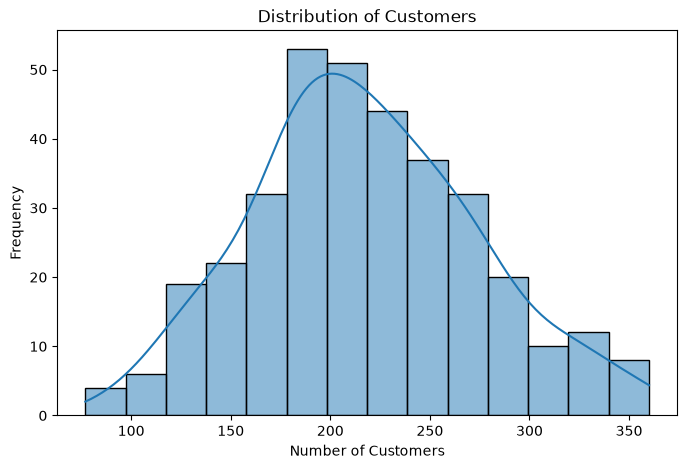

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Customers'], kde=True)
plt.title('Distribution of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Frequency')
plt.show()

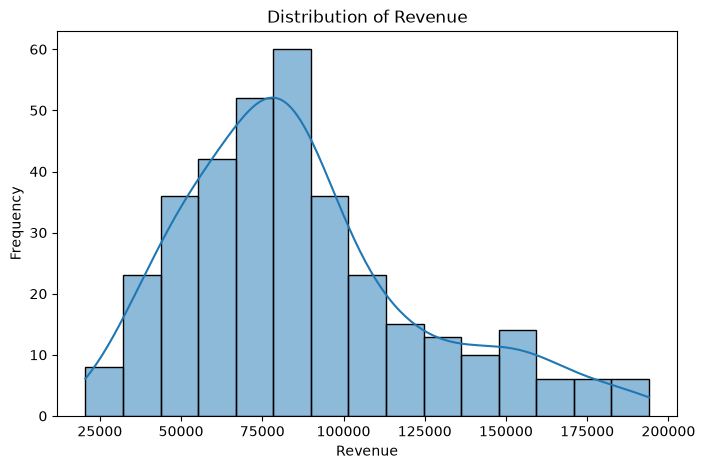

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

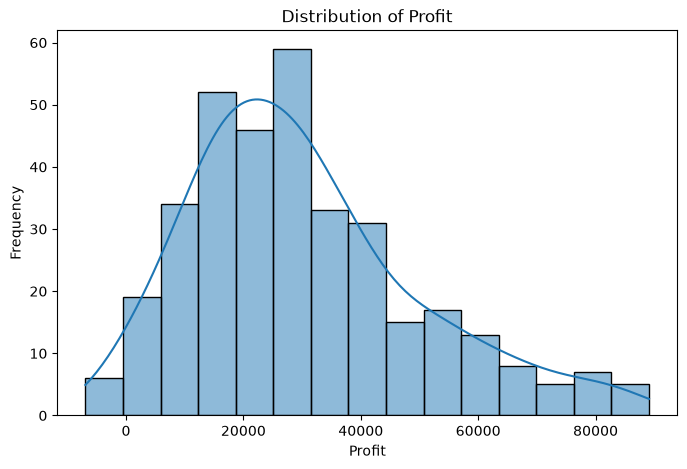

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

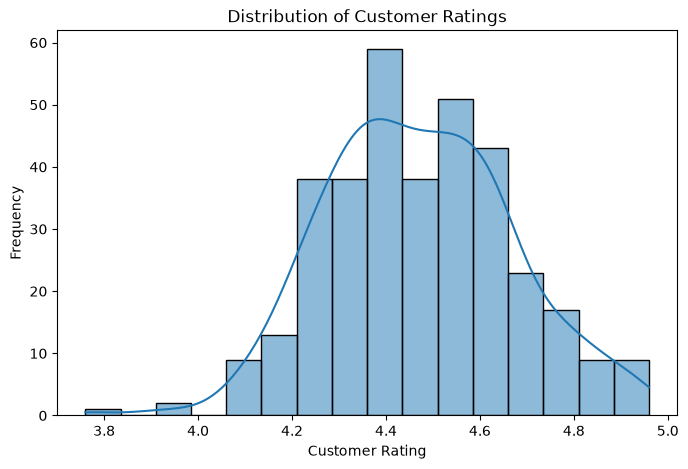

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Customer_Rating'], kde=True)
plt.title('Distribution of Customer Ratings')
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')
plt.show()

### Distribution Analysis Observation

The distribution plots show how customer numbers, revenue, profit, and customer ratings vary across restaurant records. These visualizations help identify the typical range of values and whether any variables show noticeable skewness or unusual observations.

## 8. Outlier and Spread Analysis

Boxplots are used to examine the spread of important numerical variables and identify possible extreme observations.

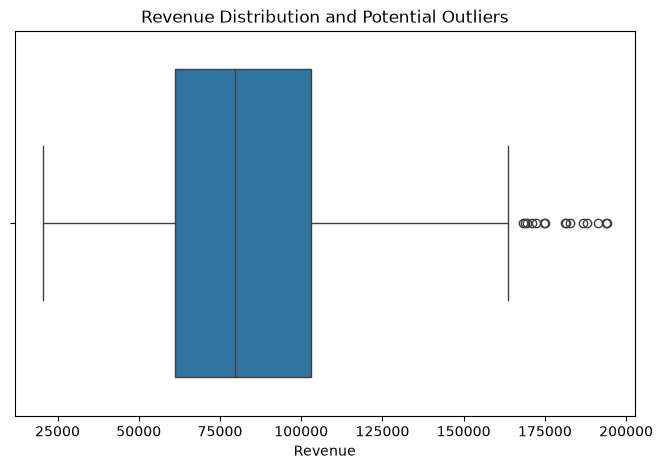

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Revenue'])
plt.title('Revenue Distribution and Potential Outliers')
plt.xlabel('Revenue')
plt.show()

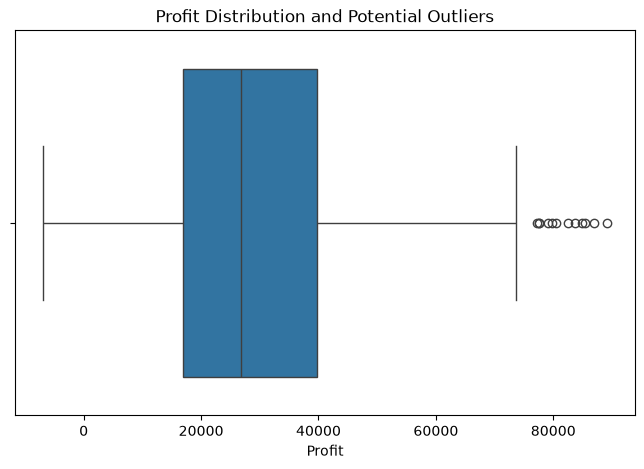

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])
plt.title('Profit Distribution and Potential Outliers')
plt.xlabel('Profit')
plt.show()

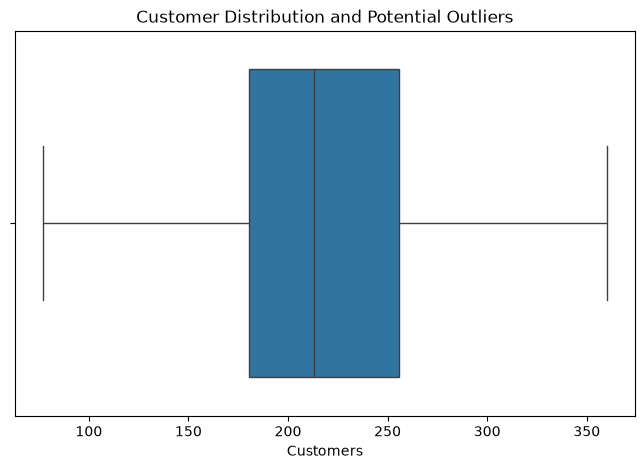

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Customers'])
plt.title('Customer Distribution and Potential Outliers')
plt.xlabel('Customers')
plt.show()

## 9. Performance Comparison Across Branches

Restaurant performance can vary between branches.

We calculate the average number of customers, revenue, profit, marketing spend, staff count, delivery time, and customer rating for each branch.

In [23]:
branch_performance = df.groupby('Branch')[ ['Customers', 'Revenue','Profit', 'Marketing_Spend', 'Staff_Count','Avg_Delivery_Min','Customer_Rating']].mean().round(2)
branch_performance

,Customers,Revenue,Profit,Marketing_Spend,Staff_Count,Avg_Delivery_Min,Customer_Rating
Branch,,,,,,,
Bengaluru,227.50,90732.12,31890.91,5413.93,12.85,26.56,4.47
Delhi,213.97,87573.87,31385.30,5762.63,11.56,25.69,4.49
Hyderabad,220.79,88804.90,31402.98,5455.15,12.28,25.52,4.47
Jaipur,223.27,86746.16,30469.70,5356.64,11.71,26.58,4.47
Kochi,209.06,85574.62,28902.04,5660.43,11.83,25.84,4.42
Mumbai,213.77,80779.25,26580.99,5580.10,10.89,26.86,4.44
Pune,214.92,88107.49,31265.57,5590.57,11.86,25.53,4.54
Srinagar,214.73,86746.47,30302.92,5413.67,12.46,25.97,4.48


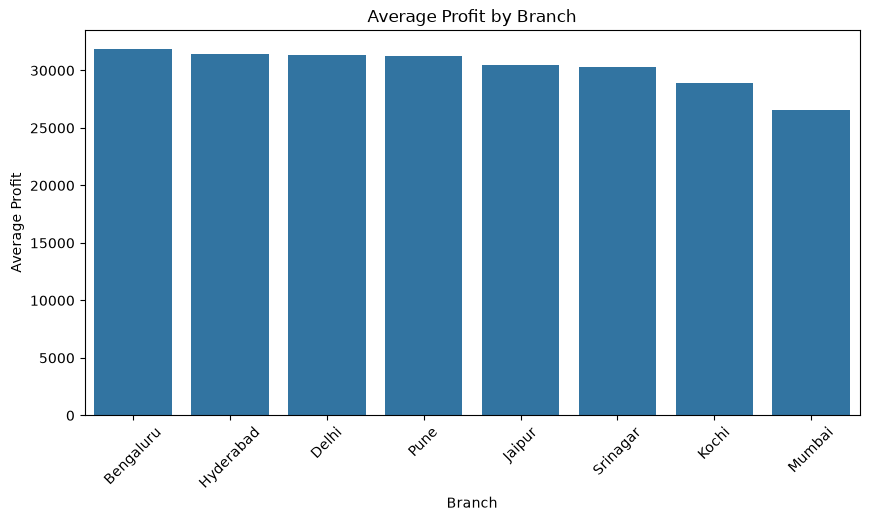

In [24]:
plt.figure(figsize=(10,5))
branch_profit = df.groupby('Branch')['Profit'].mean().sort_values(ascending=False)
sns.barplot(x=branch_profit.index, y=branch_profit.values)
plt.title('Average Profit by Branch')
plt.xlabel('Branch')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()

From the actual dataset, Bengaluru has the highest average revenue and average profit, while Mumbai has the lowest average revenue and average profit.

## 10. Performance Comparison Across Regions

The dataset contains three regions: North, South, and West.

Comparing these regions helps determine whether restaurant performance differs geographically.

In [26]:
region_performance = df.groupby('Region')[
    ['Customers',
     'Revenue',
     'Profit',
     'Marketing_Spend',
     'Staff_Count',
     'Avg_Delivery_Min',
     'Customer_Rating']
].mean().round(2)

region_performance

,Customers,Revenue,Profit,Marketing_Spend,Staff_Count,Avg_Delivery_Min,Customer_Rating
Region,,,,,,,
North,217.65,86946.94,30625.96,5477.53,11.97,26.13,4.48
South,218.93,88320.22,30690.57,5513.23,12.31,25.98,4.45
West,214.30,84126.72,28720.86,5584.88,11.33,26.25,4.49


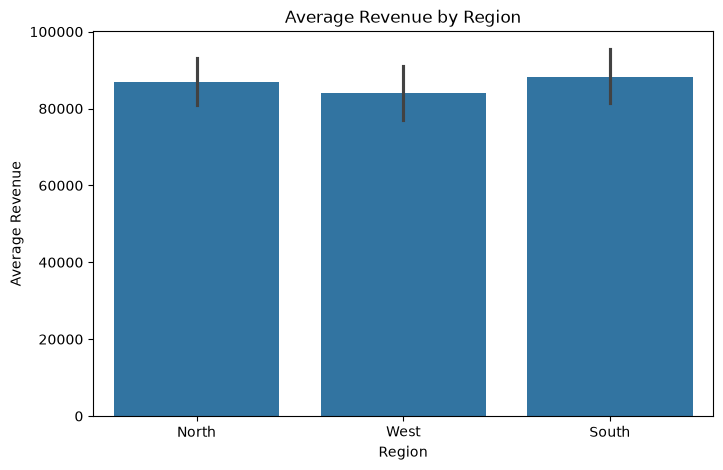

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Region',
    y='Revenue',
    estimator='mean'
)
plt.title('Average Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Average Revenue')
plt.show()